## 基本图像推理


image 1/1 /home/jetson/Project/littlecar2/vision/yolo_dataset/images/val/sim_val_00001.jpg: 320x320 2 Greens, 1 Blue, 23.8ms
Speed: 2.6ms preprocess, 23.8ms inference, 29.1ms postprocess per image at shape (1, 3, 320, 320)
{'class_id': 2, 'class_name': 'Blue', 'confidence': 0.9857, 'box': [256, 225, 444, 397], 'center': [350, 311]}
{'class_id': 1, 'class_name': 'Green', 'confidence': 0.9731, 'box': [444, 381, 603, 530], 'center': [523, 455]}
{'class_id': 1, 'class_name': 'Green', 'confidence': 0.9714, 'box': [382, 527, 484, 628], 'center': [433, 577]}


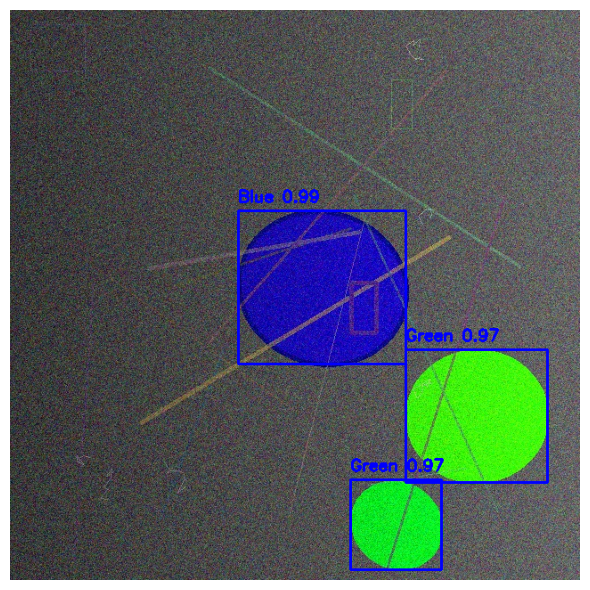

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


# ===== 路径配置 =====
MODEL_PATH = Path("/home/jetson/Project/littlecar2/vision/model/RGB_circle.pt")
IMAGE_PATH = Path("/home/jetson/Project/littlecar2/vision/yolo_dataset/images/val/sim_val_00001.jpg")


def main():
    # ===== 基础检查 =====
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"模型文件不存在: {MODEL_PATH.resolve()}")

    if not IMAGE_PATH.exists():
        raise FileNotFoundError(f"图像文件不存在: {IMAGE_PATH.resolve()}")

    # ===== 加载模型 =====
    model = YOLO(str(MODEL_PATH))

    # ===== 推理 =====
    results = model(
        source=str(IMAGE_PATH),
        conf=0.25,
        imgsz=320,
        device=0,       # Jetson GPU；如果显存不足，改成 "cpu"
        show=False,
        save=False,
        verbose=True
    )

    # ===== 读取原图 =====
    img = cv2.imread(str(IMAGE_PATH))
    if img is None:
        raise RuntimeError(f"OpenCV 读取图像失败: {IMAGE_PATH.resolve()}")

    # ===== 绘制检测框 =====
    for r in results:
        boxes = r.boxes
        names = r.names

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])
            cls_name = names[cls_id]

            label = f"{cls_name} {conf:.2f}"

            cv2.rectangle(
                img,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            cv2.putText(
                img,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2

            print({
                "class_id": cls_id,
                "class_name": cls_name,
                "confidence": round(conf, 4),
                "box": [x1, y1, x2, y2],
                "center": [cx, cy]
            })

    # ===== 在 VS Code / Remote-SSH 中显示结果 =====
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

## 摄像头

In [6]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)

ret, frame = cap.read()

if not ret:
    raise RuntimeError("无法读取摄像头图像")

# OpenCV是BGR，matplotlib要RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

[ WARN:0@55.301] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[video4linux2,v4l2 @ 0x2c101a40] ioctl(VIDIOC_G_INPUT): Inappropriate ioctl for device
[ERROR:0@55.302] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


RuntimeError: 无法读取摄像头图像

In [9]:
!v4l2-ctl --list-devices

NVIDIA Tegra Video Input Device (platform:tegra-camrtc-ca):
	/dev/media0

USB Camera: USB Camera (usb-3610000.usb-2.3):
	/dev/video2
	/dev/video3
	/dev/media2

USB Camera: USB Camera (usb-3610000.usb-2.4):
	/dev/video0
	/dev/video1
	/dev/media1



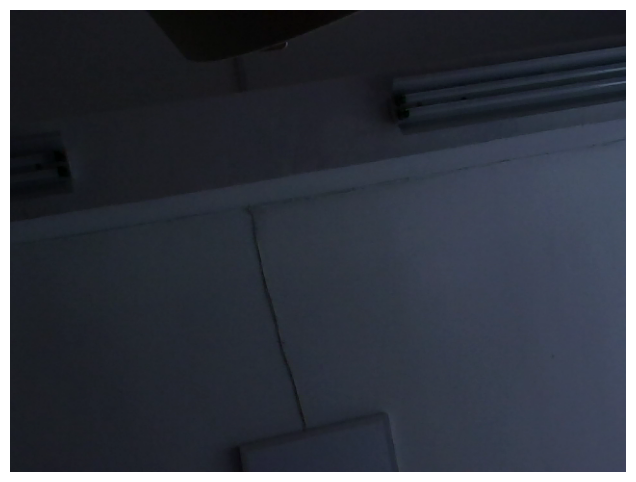

In [11]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("/dev/video2", cv2.CAP_V4L2)

if not cap.isOpened():
    raise RuntimeError("无法打开 /dev/video0，可能被占用或设备异常")

ret, frame = cap.read()

cap.release()   # 必须释放摄像头，不是窗口操作

if not ret:
    raise RuntimeError("打开了摄像头，但没有读到图像帧")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

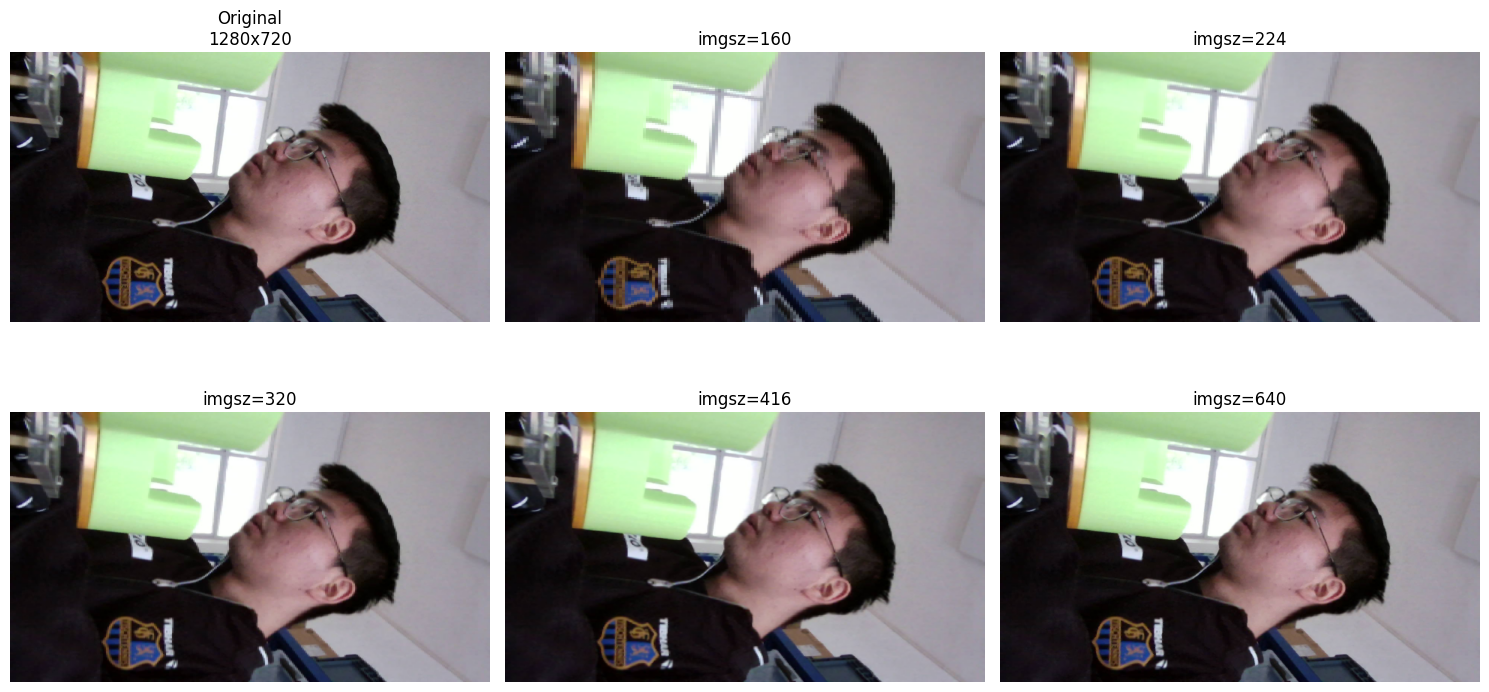

In [18]:
import cv2
import matplotlib.pyplot as plt

# ---------- 拍一张照片 ----------
cap = cv2.VideoCapture("/dev/video0", cv2.CAP_V4L2)

cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
cap.set(cv2.CAP_PROP_FRAME_WIDTH,1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,720)

# 丢掉前几帧
for _ in range(5):
    cap.read()

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("拍照失败")

img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# ---------- 多尺寸比较 ----------
sizes = [160,224,320,416,640]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15,8)
)

axes = axes.ravel()

# 原图
axes[0].imshow(img)
axes[0].set_title(
f"Original\n{img.shape[1]}x{img.shape[0]}"
)
axes[0].axis("off")


for i, s in enumerate(sizes):

    # 降采样到YOLO输入尺寸
    down = cv2.resize(
        img,
        (s,s),
        interpolation=cv2.INTER_AREA
    )

    # 放大回来方便肉眼观察损失
    up = cv2.resize(
        down,
        (img.shape[1], img.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    axes[i+1].imshow(up)
    axes[i+1].set_title(f"imgsz={s}")
    axes[i+1].axis("off")


plt.tight_layout()
plt.show()

## 推理耗时统计

加载 YOLO 模型...

===== 测试 imgsz=160 =====
imgsz=160 | frame=000 | cap=8.68ms | infer=29.21ms | total=37.89ms | fps=26.39 | det=1
imgsz=160 | frame=001 | cap=8.63ms | infer=29.26ms | total=37.89ms | fps=26.39 | det=1
imgsz=160 | frame=002 | cap=8.60ms | infer=29.12ms | total=37.71ms | fps=26.51 | det=1
imgsz=160 | frame=003 | cap=8.58ms | infer=28.94ms | total=37.52ms | fps=26.65 | det=1
imgsz=160 | frame=004 | cap=8.44ms | infer=29.01ms | total=37.45ms | fps=26.70 | det=1
imgsz=160 | frame=005 | cap=8.50ms | infer=28.94ms | total=37.45ms | fps=26.70 | det=1
imgsz=160 | frame=006 | cap=8.46ms | infer=30.21ms | total=38.68ms | fps=25.85 | det=1
imgsz=160 | frame=007 | cap=8.28ms | infer=29.05ms | total=37.33ms | fps=26.79 | det=1
imgsz=160 | frame=008 | cap=9.00ms | infer=28.97ms | total=37.97ms | fps=26.34 | det=1
imgsz=160 | frame=009 | cap=9.05ms | infer=28.89ms | total=37.94ms | fps=26.35 | det=1
imgsz=160 | frame=010 | cap=8.97ms | infer=28.96ms | total=37.93ms | fps=26.36 | det=1
img

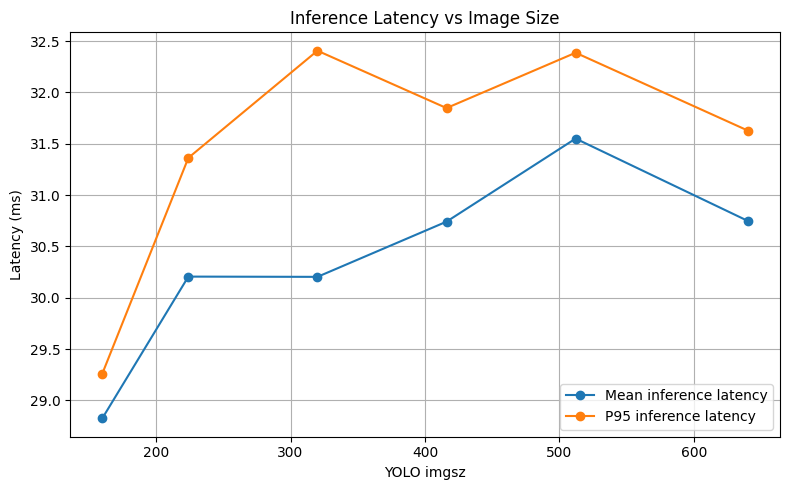

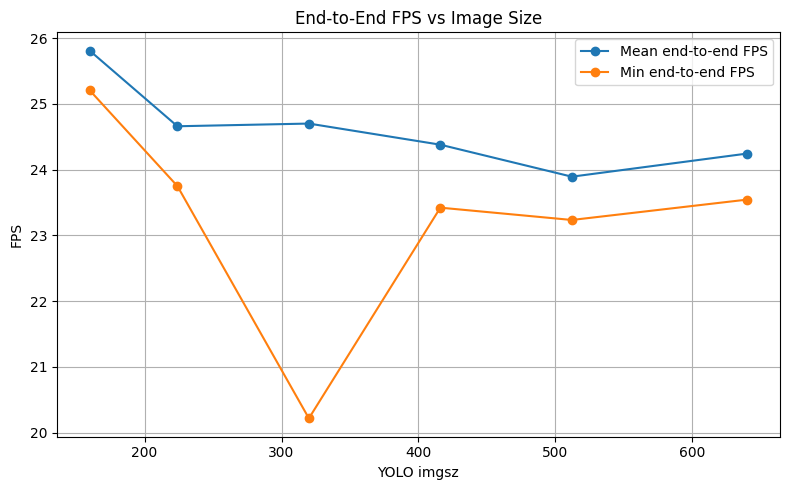

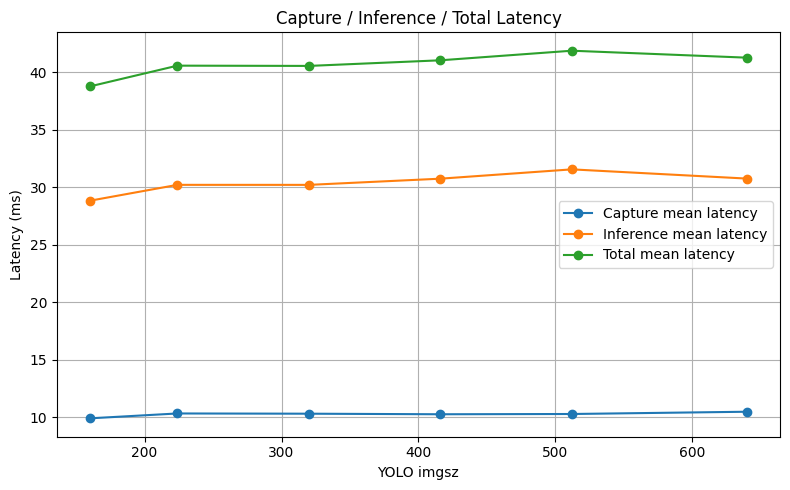

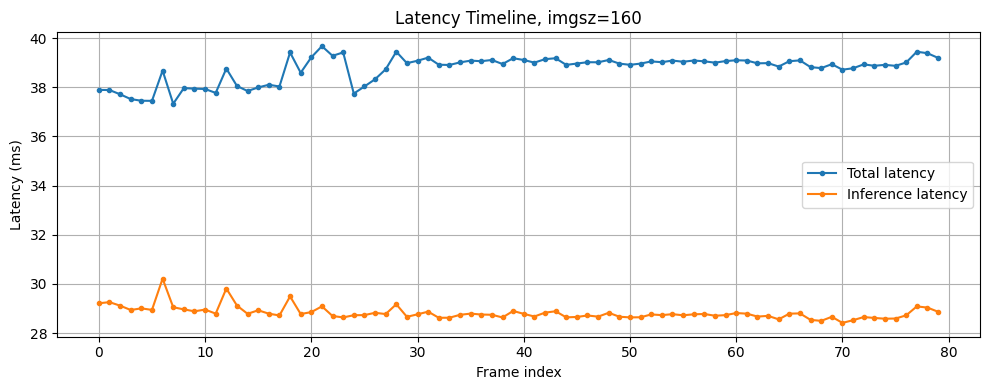

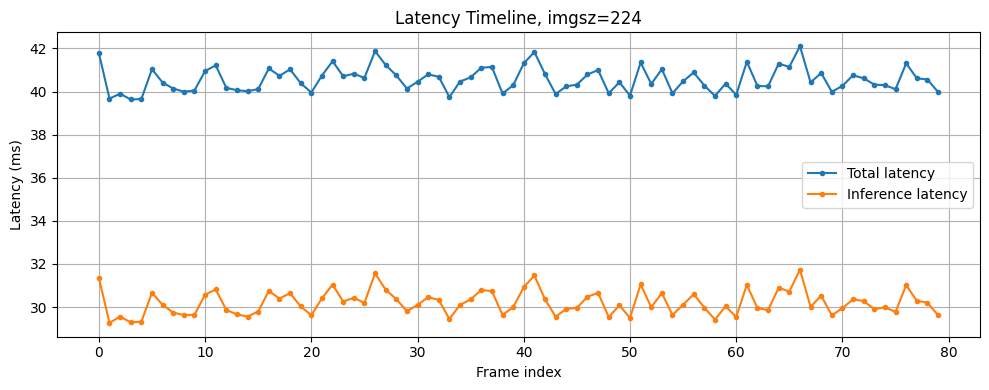

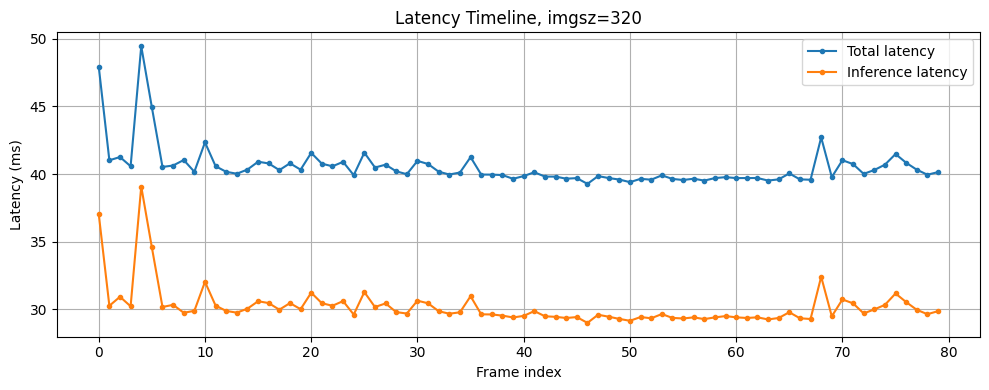

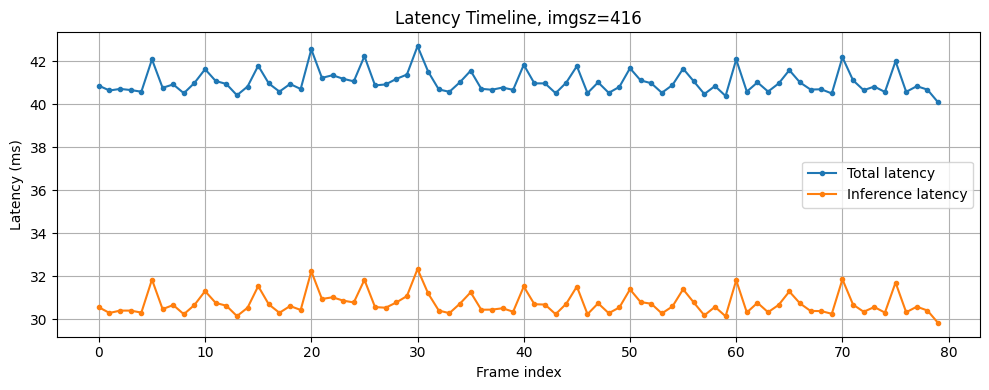

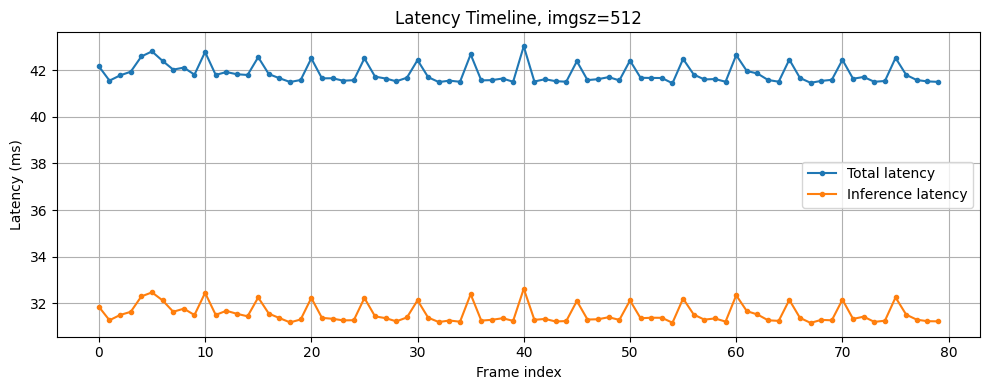

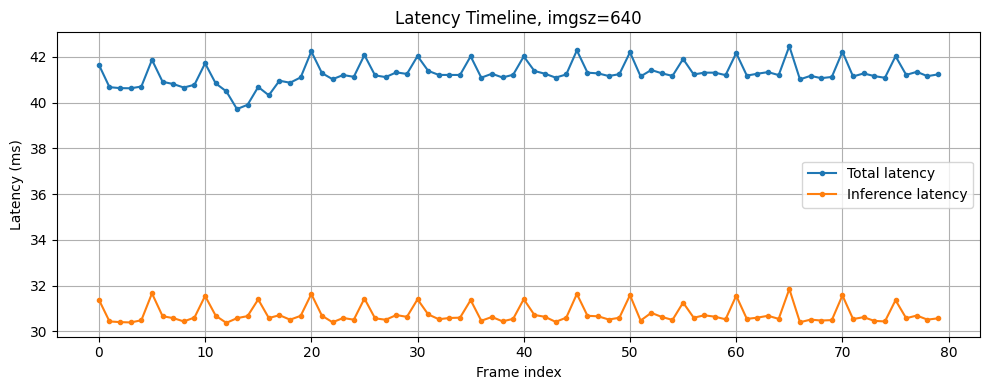

In [14]:
from pathlib import Path
import time
import statistics

import cv2
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO


# ================= 配置区 =================
MODEL_PATH = Path("/home/jetson/Project/littlecar2/vision/model/RGB_circle.pt")
CAMERA_PATH = "/dev/video0"

IMGSZ_LIST = [160, 224, 320, 416, 512, 640]
CONF = 0.25
DEVICE = 0

FRAME_WIDTH = 1280
FRAME_HEIGHT = 720
CAMERA_FPS = 30

WARMUP_FRAMES = 10
TEST_FRAMES_PER_SIZE = 80

SAVE_DIR = Path("/home/jetson/Project/littlecar2/vision/benchmark_results")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
# =========================================


def open_camera():
    cap = cv2.VideoCapture(CAMERA_PATH, cv2.CAP_V4L2)

    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"MJPG"))
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_WIDTH)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_HEIGHT)
    cap.set(cv2.CAP_PROP_FPS, CAMERA_FPS)

    if not cap.isOpened():
        raise RuntimeError(f"无法打开摄像头: {CAMERA_PATH}")

    return cap


def percentile(values, p):
    values = sorted(values)
    idx = int(len(values) * p / 100)
    idx = min(idx, len(values) - 1)
    return values[idx]


def benchmark_one_size(model, cap, imgsz):
    print(f"\n===== 测试 imgsz={imgsz} =====")

    # 摄像头预热
    for _ in range(WARMUP_FRAMES):
        cap.read()

    # 模型预热
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError("摄像头预热读取失败")

    for _ in range(3):
        model(frame, conf=CONF, imgsz=imgsz, device=DEVICE, verbose=False)

    records = []

    for i in range(TEST_FRAMES_PER_SIZE):
        total_t0 = time.perf_counter()

        # 拍摄
        cap_t0 = time.perf_counter()
        ret, frame = cap.read()
        cap_t1 = time.perf_counter()

        if not ret or frame is None:
            print(f"第 {i} 帧读取失败，跳过")
            continue

        # 推理
        infer_t0 = time.perf_counter()
        results = model(
            frame,
            conf=CONF,
            imgsz=imgsz,
            device=DEVICE,
            verbose=False
        )
        infer_t1 = time.perf_counter()

        total_t1 = time.perf_counter()

        det_count = 0
        for r in results:
            det_count += len(r.boxes)

        capture_ms = (cap_t1 - cap_t0) * 1000
        infer_ms = (infer_t1 - infer_t0) * 1000
        total_ms = (total_t1 - total_t0) * 1000

        records.append({
            "imgsz": imgsz,
            "frame_idx": i,
            "capture_ms": capture_ms,
            "infer_ms": infer_ms,
            "total_ms": total_ms,
            "fps_total": 1000 / total_ms if total_ms > 0 else 0,
            "fps_infer": 1000 / infer_ms if infer_ms > 0 else 0,
            "det_count": det_count,
        })

        print(
            f"imgsz={imgsz} | frame={i:03d} | "
            f"cap={capture_ms:.2f}ms | "
            f"infer={infer_ms:.2f}ms | "
            f"total={total_ms:.2f}ms | "
            f"fps={1000 / total_ms:.2f} | "
            f"det={det_count}"
        )

    return records


def summarize(df):
    rows = []

    for imgsz, group in df.groupby("imgsz"):
        row = {
            "imgsz": imgsz,

            "capture_mean_ms": group["capture_ms"].mean(),
            "capture_p95_ms": percentile(group["capture_ms"].tolist(), 95),

            "infer_mean_ms": group["infer_ms"].mean(),
            "infer_median_ms": group["infer_ms"].median(),
            "infer_p95_ms": percentile(group["infer_ms"].tolist(), 95),
            "infer_max_ms": group["infer_ms"].max(),

            "total_mean_ms": group["total_ms"].mean(),
            "total_median_ms": group["total_ms"].median(),
            "total_p95_ms": percentile(group["total_ms"].tolist(), 95),
            "total_max_ms": group["total_ms"].max(),

            "fps_total_mean": group["fps_total"].mean(),
            "fps_total_min": group["fps_total"].min(),

            "det_count_mean": group["det_count"].mean(),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def plot_summary(summary_df):
    # 1. 推理耗时随尺寸变化
    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["imgsz"], summary_df["infer_mean_ms"], marker="o", label="Mean inference latency")
    plt.plot(summary_df["imgsz"], summary_df["infer_p95_ms"], marker="o", label="P95 inference latency")
    plt.xlabel("YOLO imgsz")
    plt.ylabel("Latency (ms)")
    plt.title("Inference Latency vs Image Size")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "latency_vs_imgsz.png", dpi=200)
    plt.show()

    # 2. 端到端 FPS 随尺寸变化
    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["imgsz"], summary_df["fps_total_mean"], marker="o", label="Mean end-to-end FPS")
    plt.plot(summary_df["imgsz"], summary_df["fps_total_min"], marker="o", label="Min end-to-end FPS")
    plt.xlabel("YOLO imgsz")
    plt.ylabel("FPS")
    plt.title("End-to-End FPS vs Image Size")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "fps_vs_imgsz.png", dpi=200)
    plt.show()

    # 3. 拍摄耗时 vs 推理耗时
    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["imgsz"], summary_df["capture_mean_ms"], marker="o", label="Capture mean latency")
    plt.plot(summary_df["imgsz"], summary_df["infer_mean_ms"], marker="o", label="Inference mean latency")
    plt.plot(summary_df["imgsz"], summary_df["total_mean_ms"], marker="o", label="Total mean latency")
    plt.xlabel("YOLO imgsz")
    plt.ylabel("Latency (ms)")
    plt.title("Capture / Inference / Total Latency")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "latency_components.png", dpi=200)
    plt.show()


def plot_timeline(df):
    # 持续运行稳定性：每个尺寸单独看 total_ms 时间序列
    for imgsz, group in df.groupby("imgsz"):
        plt.figure(figsize=(10, 4))
        plt.plot(group["frame_idx"], group["total_ms"], marker=".", label="Total latency")
        plt.plot(group["frame_idx"], group["infer_ms"], marker=".", label="Inference latency")
        plt.xlabel("Frame index")
        plt.ylabel("Latency (ms)")
        plt.title(f"Latency Timeline, imgsz={imgsz}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(SAVE_DIR / f"timeline_imgsz_{imgsz}.png", dpi=200)
        plt.show()


def main():
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"模型不存在: {MODEL_PATH}")

    print("加载 YOLO 模型...")
    model = YOLO(str(MODEL_PATH))

    cap = open_camera()

    all_records = []

    try:
        for imgsz in IMGSZ_LIST:
            records = benchmark_one_size(model, cap, imgsz)
            all_records.extend(records)

    finally:
        cap.release()

    df = pd.DataFrame(all_records)
    summary_df = summarize(df)

    raw_csv = SAVE_DIR / "raw_benchmark.csv"
    summary_csv = SAVE_DIR / "summary_benchmark.csv"

    df.to_csv(raw_csv, index=False)
    summary_df.to_csv(summary_csv, index=False)

    print("\n===== 汇总结果 =====")
    print(summary_df)

    print(f"\n原始数据已保存: {raw_csv}")
    print(f"汇总数据已保存: {summary_csv}")

    plot_summary(summary_df)
    plot_timeline(df)


if __name__ == "__main__":
    main()

## 硬件加速

In [23]:
!conda activate yolo_env
!export PYTHONNOUSERSITE=1
!which python
!which yolo
!python -c "import ultralytics; print(ultralytics.__file__)"
!python -c "import site; print(site.ENABLE_USER_SITE)"
!python -c "import ultralytics; print(ultralytics.__file__)"


CondaError: Run 'conda init' before 'conda activate'

/home/jetson/miniconda3/envs/yolo_env/bin/python
/home/jetson/.local/bin/yolo
/home/jetson/.local/lib/python3.10/site-packages/ultralytics/__init__.py
True
/home/jetson/.local/lib/python3.10/site-packages/ultralytics/__init__.py


In [2]:
from ultralytics import YOLO

MODEL_PATH = "/home/jetson/Project/littlecar2/vision/model/RGB_circle.pt"

model = YOLO(MODEL_PATH)

model.export(
    format="onnx",
    imgsz=320,
    device="cpu",      # 先用 CPU 导 ONNX，避免 Jetson CUDA 内存问题
    simplify=False,
)

Ultralytics 8.4.8 🚀 Python-3.10.19 torch-2.8.0 CPU (ARMv8 Processor rev 1 (v8l))
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/jetson/Project/littlecar2/vision/model/RGB_circle.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.9 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


/home/jetson/.local/lib/python3.10/site-packages/torch/onnx/utils.py:1397: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: export success ✅ 1.3s, saved as '/home/jetson/Project/littlecar2/vision/model/RGB_circle.onnx' (11.6 MB)

Export complete (2.0s)
Results saved to /home/jetson/Project/littlecar2/vision/model
Predict:         yolo predict task=detect model=/home/jetson/Project/littlecar2/vision/model/RGB_circle.onnx imgsz=320 
Validate:        yolo val task=detect model=/home/jetson/Project/littlecar2/vision/model/RGB_circle.onnx imgsz=320 data=/datasets/rgbcirclegeneration/data.yaml  
Visualize:       https://netron.app


'/home/jetson/Project/littlecar2/vision/model/RGB_circle.onnx'

In [ ]:
from ultralytics import YOLO

model = YOLO("/home/jetson/Project/littlecar2/vision/model/RGB_circle.pt")

model.export(
    format="engine",
    imgsz=320,
    device=0,
    half=True,
    workspace=1,
    simplify=False,
)

: 

执行命令：
!python - <<'PY'
from ultralytics import YOLO

model = YOLO("/home/jetson/Project/littlecar2/vision/model/RGB_circle.pt")

model.export(
    format="engine",
    imgsz=320,
    device=0,
    half=True,
    workspace=1,
    simplify=False,
)
PY